In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn import metrics
%matplotlib inline
import missingno as msno

In [30]:
data = pd.read_csv(r'C:\Users\aliye\Desktop\QSS(DSA)\python\week-6\day-1\loan_prediction.csv')
df = data.copy()
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [31]:
df.drop(['Loan_ID'], axis=1, inplace=True)
for column in df.columns:
    print(f"Unique values in column '{column}': {df[column].unique()}")
    print()


Unique values in column 'Gender': ['Male' 'Female' nan]

Unique values in column 'Married': ['No' 'Yes' nan]

Unique values in column 'Dependents': ['0' '1' '2' '3+' nan]

Unique values in column 'Education': ['Graduate' 'Not Graduate']

Unique values in column 'Self_Employed': ['No' 'Yes' nan]

Unique values in column 'ApplicantIncome': [ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  2500
  3073  1853  1299  4950  3596  3510  4887  2600  7660  5955  3365  3717
  9560  2799  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828
  3667  3748  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000
  1928  3086  4230  4616 11500  2708  2132  3366  8080  3357  3029  2609
  4945  5726 10750  7100  4300  3208  1875  4755  5266  1000  3333  3846
  2395  1378  3988  2366  8566  5695  2958  6250  3273  4133  3620  6782
  2484  1977  4188  1759  4288  4843 13650  4652  3816  3052 11417  7333
  3800  2071  5316  2929  3572  7451  5050 14583  2214  5568 10408  5667
  2

In [32]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
#df.drop(['Loan_ID'], axis=1, inplace=True)
for column in df.columns:
    print(f"Unique values in column '{column}': {df[column].unique()}")
    print()

Unique values in column 'Gender': ['Male' 'Female']

Unique values in column 'Married': ['No' 'Yes']

Unique values in column 'Dependents': ['0' '1' '2' '3+']

Unique values in column 'Education': ['Graduate' 'Not Graduate']

Unique values in column 'Self_Employed': ['No' 'Yes']

Unique values in column 'ApplicantIncome': [ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  2500
  3073  1853  1299  4950  3596  3510  4887  2600  7660  5955  3365  3717
  9560  2799  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828
  3667  3748  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000
  1928  3086  4230  4616 11500  2708  2132  3366  8080  3357  3029  2609
  4945  5726 10750  7100  4300  3208  1875  4755  5266  1000  3333  3846
  2395  1378  3988  2366  8566  5695  2958  6250  3273  4133  3620  6782
  2484  1977  4188  1759  4288  4843 13650  4652  3816  3052 11417  7333
  3800  2071  5316  2929  3572  7451  5050 14583  2214  5568 10408  5667
  2137  2957  3692 

<Axes: >

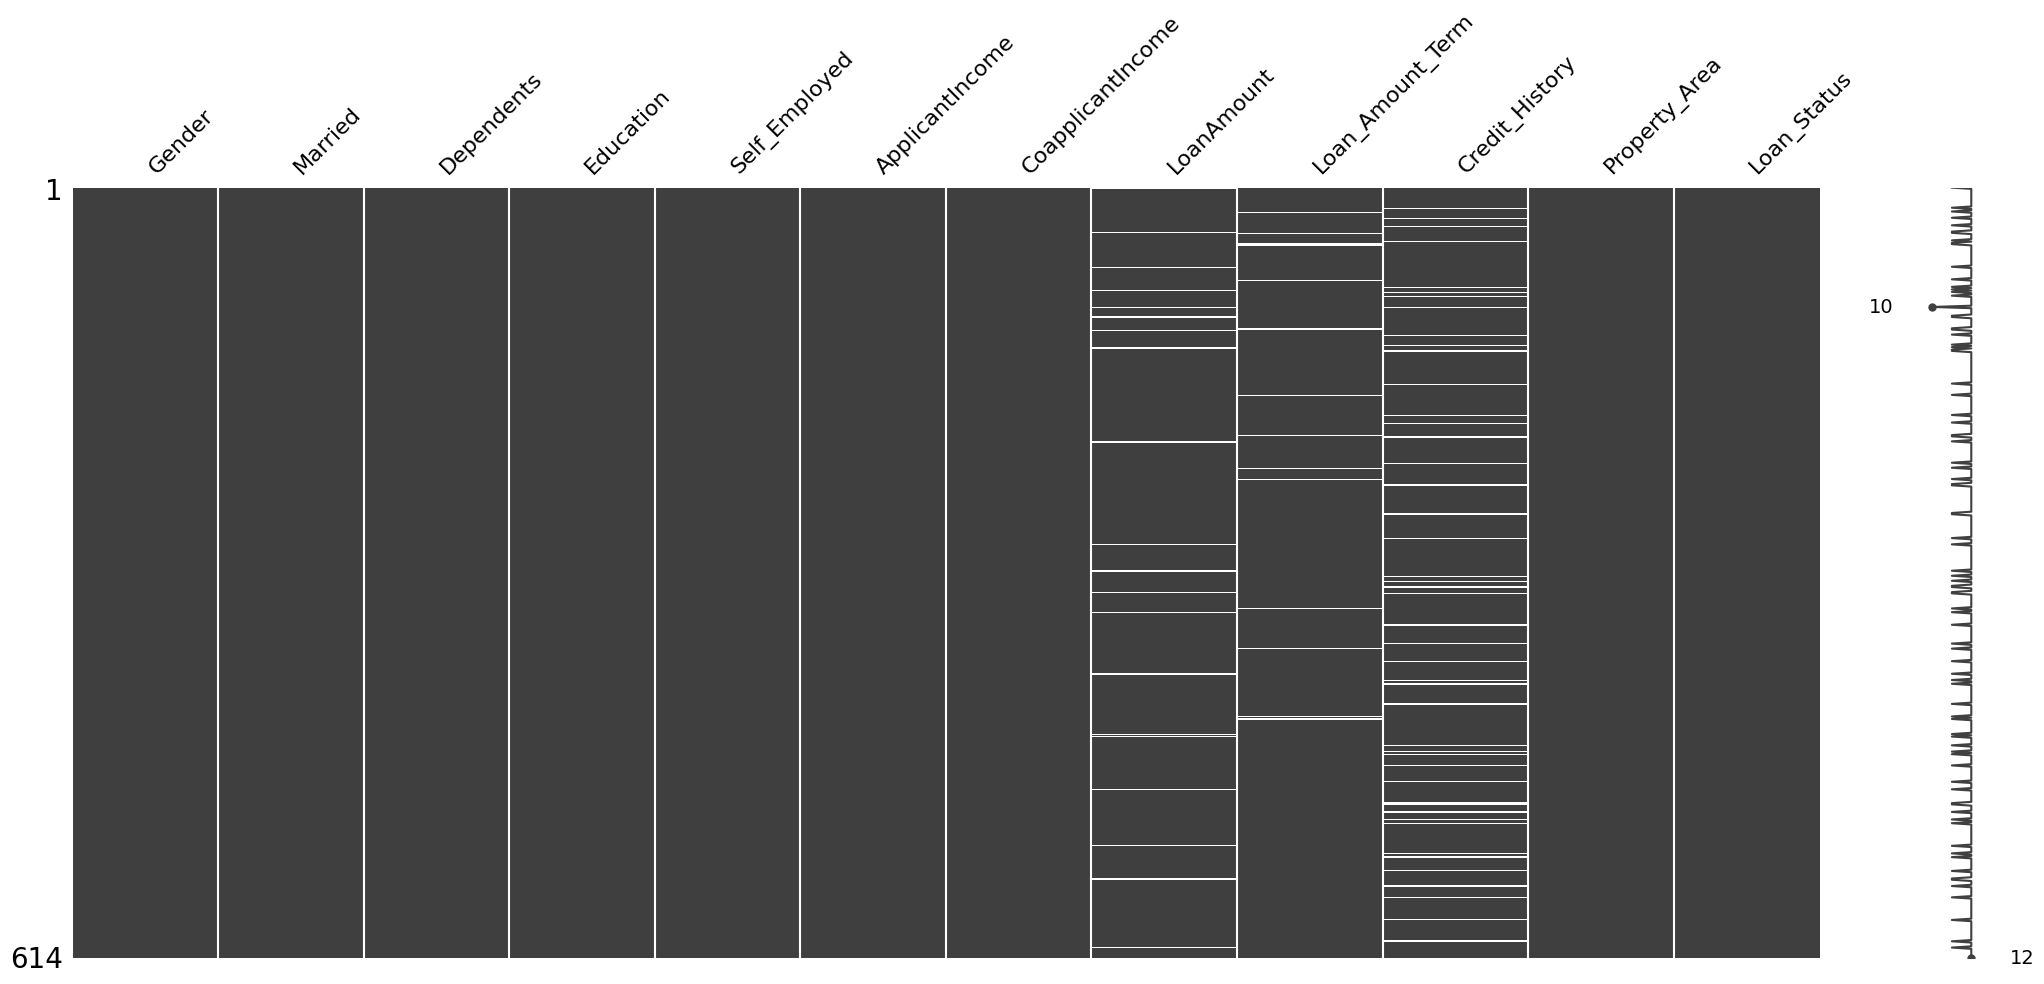

In [34]:
msno.matrix(df)

In [35]:
# categorical columns 
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']:
    df[col] = df[col].fillna(df[col].mode()[0])

<Axes: >

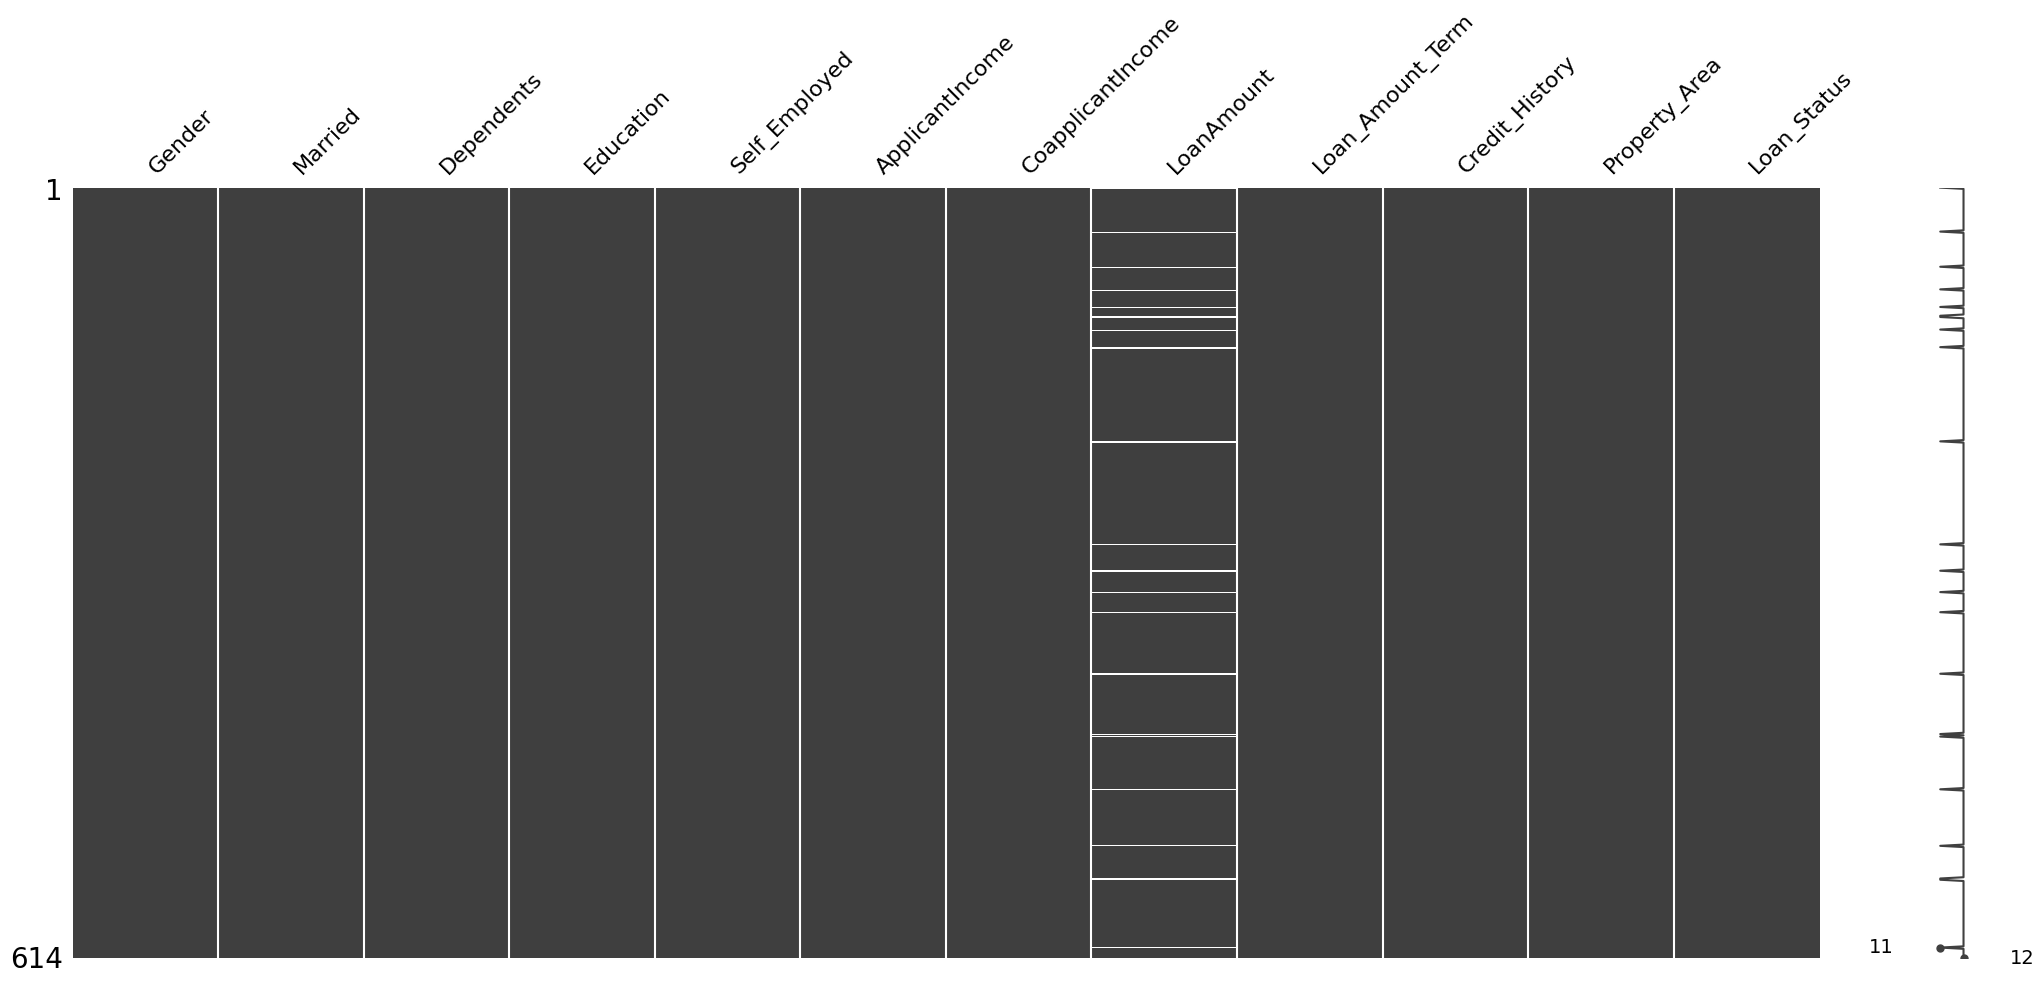

In [36]:
msno.matrix(df)

In [37]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

<Axes: >

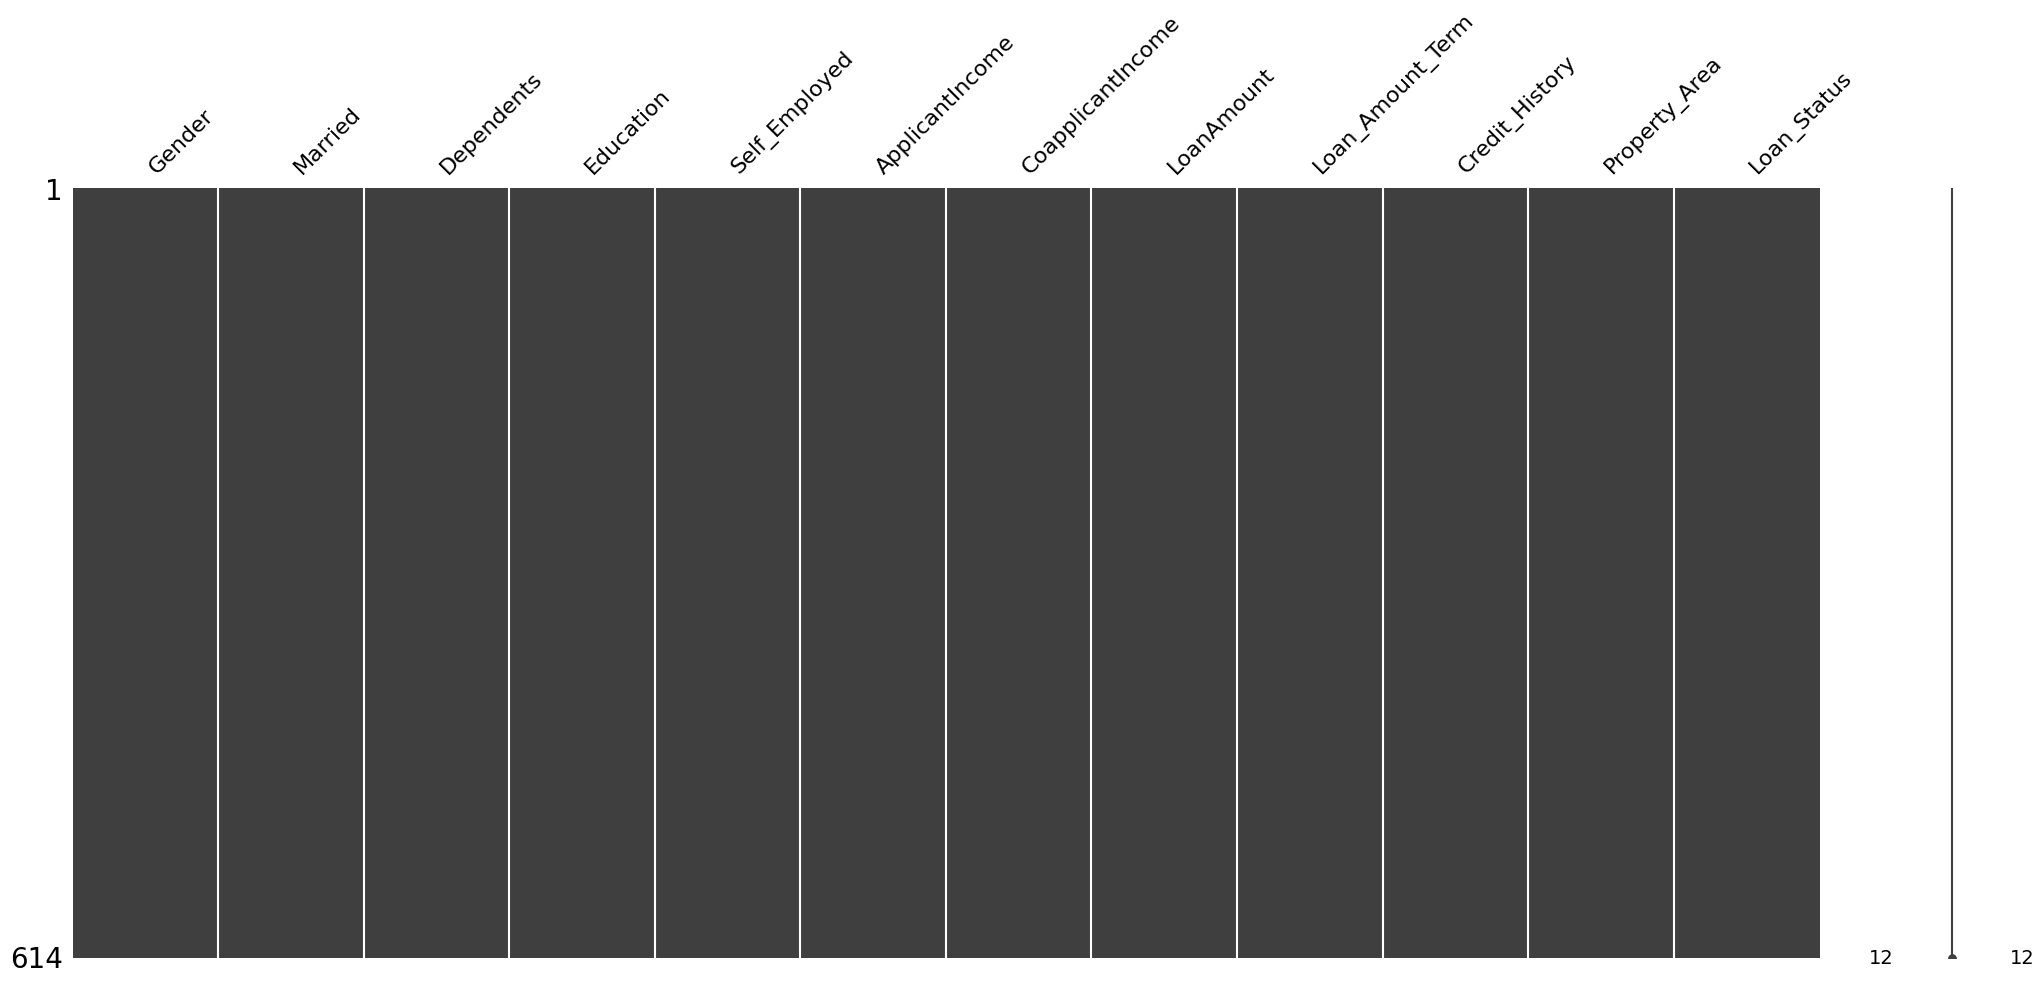

In [38]:
msno.matrix(df)

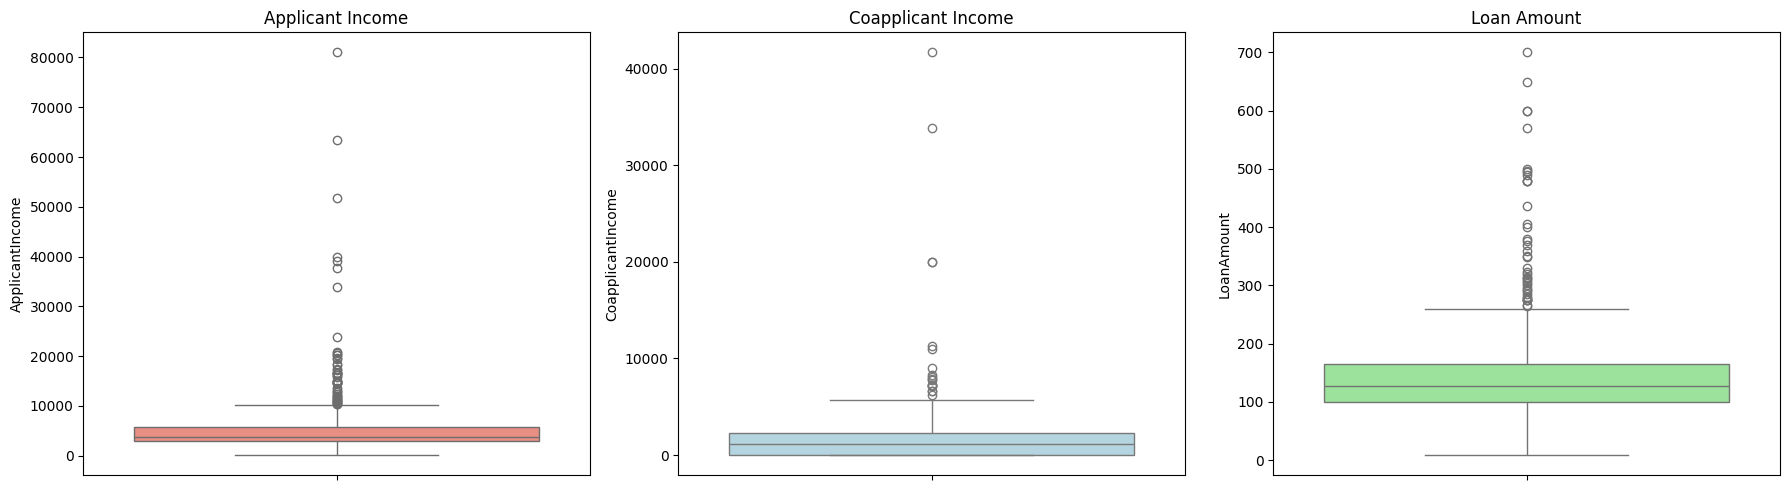

In [39]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], y=df['ApplicantIncome'], color='salmon')
axes[0].set_title('Applicant Income')

sns.boxplot(ax=axes[1], y=df['CoapplicantIncome'], color='lightblue')
axes[1].set_title('Coapplicant Income')

sns.boxplot(ax=axes[2], y=df['LoanAmount'], color='lightgreen')
axes[2].set_title('Loan Amount')

plt.tight_layout() # Qrafiklərin bir-birinin üstünə minməsinin qarşısını alır
plt.show()

In [40]:
outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Number of rows after removing outliers: {len(df)}")

Number of rows after removing outliers: 445


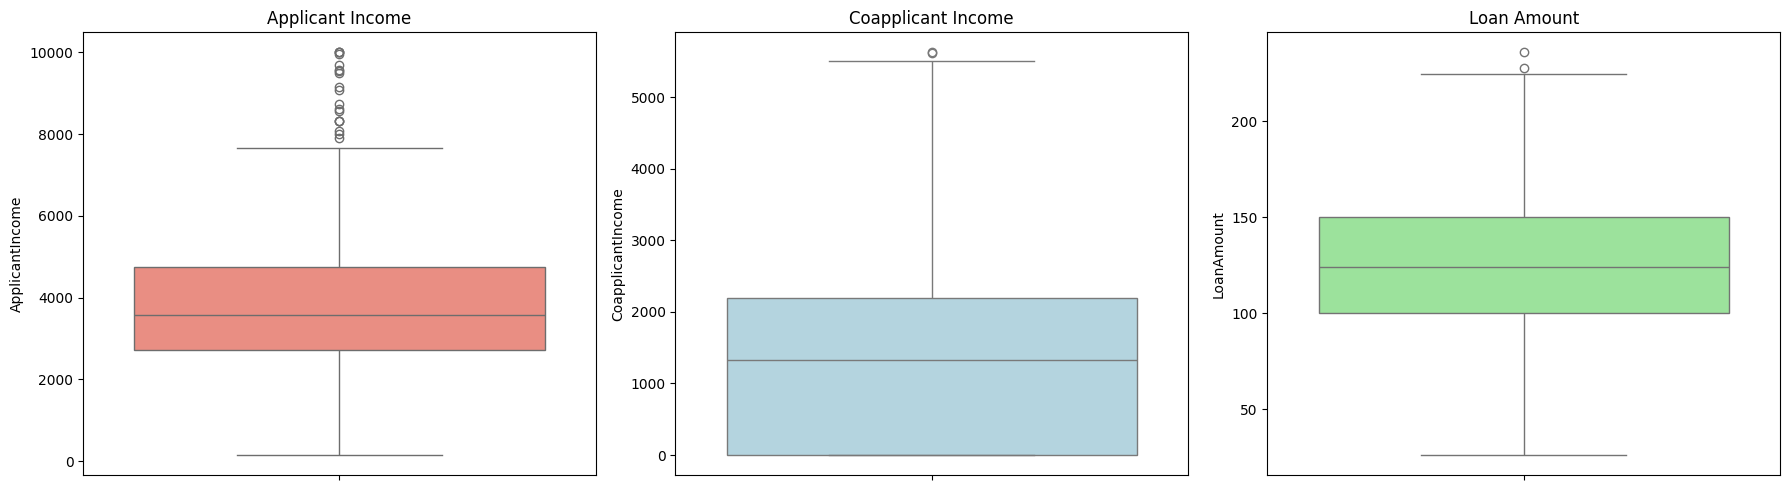

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], y=df['ApplicantIncome'], color='salmon')
axes[0].set_title('Applicant Income')

sns.boxplot(ax=axes[1], y=df['CoapplicantIncome'], color='lightblue')
axes[1].set_title('Coapplicant Income')

sns.boxplot(ax=axes[2], y=df['LoanAmount'], color='lightgreen')
axes[2].set_title('Loan Amount')

plt.tight_layout() 
plt.show()

In [42]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [43]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
607,Male,Yes,2,Not Graduate,No,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [44]:
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

In [45]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,No,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,Yes,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,Yes,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,Yes,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,No,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
607,1,Yes,2,0,0,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,1,Yes,0,1,0,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,0,No,0,1,0,2900,0.0,71.0,360.0,1.0,Rural,Y
612,1,Yes,2,1,0,7583,0.0,187.0,360.0,1.0,Urban,Y


In [46]:
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})

In [47]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
607,1,1,2,0,0,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,1,1,0,1,0,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,Rural,Y
612,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,Urban,Y


In [48]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [49]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...
607,1,1,2,0,0,3987,1411.0,157.0,360.0,1.0,Rural,1
608,1,1,0,1,0,3232,1950.0,108.0,360.0,1.0,Rural,1
609,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,Rural,1
612,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,Urban,1


In [50]:
df['Property_Area'] = df['Property_Area'].replace({'Rural': 0, 'Semiurban': 1, 'Urban': 2})

C:\Users\aliye\AppData\Local\Temp\ipykernel_8892\4274659369.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Property_Area'] = df['Property_Area'].replace({'Rural': 0, 'Semiurban': 1, 'Urban': 2})


In [51]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
607,1,1,2,0,0,3987,1411.0,157.0,360.0,1.0,0,1
608,1,1,0,1,0,3232,1950.0,108.0,360.0,1.0,0,1
609,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0,1
612,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,2,1


In [ ]:
# '3+' replace 3
df['Dependents'] = df['Dependents'].replace('3+', 3)

In [ ]:
df['Dependents'] = df['Dependents'].astype(float) # or int

In [54]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
607,1,1,2.0,0,0,3987,1411.0,157.0,360.0,1.0,0,1
608,1,1,0.0,1,0,3232,1950.0,108.0,360.0,1.0,0,1
609,0,0,0.0,1,0,2900,0.0,71.0,360.0,1.0,0,1
612,1,1,2.0,1,0,7583,0.0,187.0,360.0,1.0,2,1


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             445 non-null    int64  
 1   Married            445 non-null    int64  
 2   Dependents         445 non-null    float64
 3   Education          445 non-null    int64  
 4   Self_Employed      445 non-null    int64  
 5   ApplicantIncome    445 non-null    int64  
 6   CoapplicantIncome  445 non-null    float64
 7   LoanAmount         445 non-null    float64
 8   Loan_Amount_Term   445 non-null    float64
 9   Credit_History     445 non-null    float64
 10  Property_Area      445 non-null    int64  
 11  Loan_Status        445 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 45.2 KB


In [57]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [58]:
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

In [59]:
df['Balance_Income'] = df['Total_Income'] - (df['EMI'] * 1000) # LoanAmount minlik cinsində olduğu üçün 1000-ə vurduq

In [60]:
df.shape

(445, 15)

In [61]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Loan_Status']) 
y = df['Loan_Status'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
from sklearn.ensemble import BaggingClassifier

Bagging

In [64]:
from sklearn.svm import SVC
svm = SVC(probability=True)

In [65]:
bag = BaggingClassifier(estimator= svm,
                 n_estimators = 10,
                 max_samples = 0.4,
                 max_features = 12,
                 bootstrap = True,
                 bootstrap_features = True,
                 n_jobs = -1,
                 random_state = 123)

In [66]:
bag.fit(X_train, y_train)   

,estimator,SVC(probability=True)
,n_estimators,10
,max_samples,0.4
,max_features,12
,bootstrap,True
,bootstrap_features,True
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,123
,verbose,0


In [67]:
bag_pred = bag.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, bag_pred)

0.7640449438202247

In [ ]:
GRADIENT BOOSTING

In [69]:
from sklearn.ensemble import GradientBoostingClassifier
gbm = GradientBoostingClassifier(random_state = 123)

In [70]:
gbm.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [72]:
gbm_pred = gbm.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, gbm_pred)

0.8089887640449438

In [ ]:
xgboost 

In [74]:
import xgboost
print(xgboost.__version__)

3.1.2


In [ ]:
from xgboost import XGBClassifier
xgbt = XGBClassifier(max_depth = 2,
             learning_rate = 0.2,
             objective  = "multi:softmax",
             num_class = 2,
             booster = "gbtree",
             n_estimarors = 10,
             random_state = 123)




#overtiffitng askarlandi

In [77]:
xgbt.fit(X_train, y_train)

C:\Users\aliye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [14:41:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimarors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softmax'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [78]:
xgbt_pred = xgbt.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, xgbt_pred))


0.8089887640449438


In [80]:
xgbt.score(X_train, y_train)

0.9241573033707865

In [81]:
xgbt.score(X_test, y_test)

0.8089887640449438

catboosting

In [87]:
from catboost import CatBoostRegressor

# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=2,
                          learning_rate=1,
                          depth=2)
# Fit model
model.fit(X_train, y_train)
# Get predictions
preds = model.predict(X_test)

0:	learn: 0.3802160	total: 139ms	remaining: 139ms
1:	learn: 0.3740320	total: 140ms	remaining: 0us


In [88]:
model.score(X_train, y_train)

0.3156415079353101

In [89]:
model.score(X_test, y_test)

0.48802666101334946

Yuxarıdakı xgboost da overfitting var idi. Onun update olunmuş halı

xgboost

In [91]:
from xgboost import XGBClassifier

# early_stopping_rounds parametresini doğrudan buraya ekliyoruz
xgbt = XGBClassifier(
    n_estimators=1000,       
    learning_rate=0.05,      
    max_depth=4,             
    min_child_weight=5,      
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    early_stopping_rounds=50  # <-- Buraya taşındı
)

# .fit() içinden early_stopping_rounds kaldırıldı
xgbt.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Skorları kontrol edebilirsiniz
print("Train Score:", xgbt.score(X_train, y_train))
print("Test Score:", xgbt.score(X_test, y_test))

Train Score: 0.8455056179775281
Test Score: 0.8876404494382022


In [92]:
from sklearn.metrics import classification_report, confusion_matrix

preds = xgbt.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      0.65      0.77        26
           1       0.87      0.98      0.93        63

    accuracy                           0.89        89
   macro avg       0.91      0.82      0.85        89
weighted avg       0.89      0.89      0.88        89



catboosting en ashagi netice gosterdi. xgboost en yaxsi neticeni gosterdi.